# Hepatic spheroid feature extraction & folder comparison

This notebook:
1. Loads original images and segmentation masks from paired folders
2. Extracts morphological and intensity features inside each mask
3. Saves a CSV (one row per image)
4. Visualizes how features differ **between folders** (e.g. 24h/Cont vs treated conditions)

Re-run the extraction cell after changing paths or adding new images.

## Configuration

In [36]:
from pathlib import Path

INPUT_DIR = Path(r"D:\ToxBox\Preprocessing_KIT\Data")
MASK_DIR = Path(r"D:\ToxBox\Preprocessing_KIT\Data_segmented")
OUTPUT_CSV = Path(r"D:\ToxBox\Preprocessing_KIT\spheroid_features.csv")
FIGURES_DIR = Path(r"D:\ToxBox\Preprocessing_KIT\spheroid_feature_figures")

LOCAL_TEXTURE_WINDOW = 7

# Control (reference) folders — exact paths relative to Data root.
# Other subfolders under 24h / 48h are compared against these.
REFERENCE_FOLDERS = {
    "24h/Cont",
    "48h/Cont",
}

# Key features for comparison plots (edit as needed)
PLOT_FEATURES = [
    "area_px",
    "equivalent_diameter_px",
    "roundness",
    "eccentricity",
    "solidity",
    "mean_intensity",
    "intensity_cv",
    "local_std_mean",
]

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Feature extraction

In [37]:
import imageio.v3 as imageio
import numpy as np
import pandas as pd
from scipy import ndimage as ndi
from scipy.stats import entropy, kurtosis, skew
from skimage.filters import laplace, sobel
from skimage.measure import regionprops

FEATURE_COLUMNS = [
    "area_px", "perimeter_px", "equivalent_diameter_px",
    "major_axis_length_px", "minor_axis_length_px", "aspect_ratio",
    "eccentricity", "solidity", "extent", "roundness", "compactness",
    "bbox_width_px", "bbox_height_px", "centroid_y", "centroid_x",
    "mask_fraction_of_image",
    "mean_intensity", "median_intensity", "std_intensity",
    "min_intensity", "max_intensity", "intensity_range",
    "integrated_intensity", "intensity_cv", "intensity_skewness",
    "intensity_kurtosis", "intensity_entropy",
    "laplacian_variance", "local_std_mean", "mean_gradient_magnitude",
]


def to_grayscale(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        return image.astype(np.float64)
    return image.astype(np.float64).mean(axis=-1)


def empty_features() -> dict[str, float]:
    return {name: np.nan for name in FEATURE_COLUMNS}


def extract_features(image: np.ndarray, mask: np.ndarray) -> dict[str, float]:
    gray = to_grayscale(image)
    binary = mask > 0
    if not np.any(binary):
        return empty_features()

    labeled = binary.astype(np.uint8)
    props_list = regionprops(labeled, intensity_image=gray)
    if not props_list:
        return empty_features()

    prop = max(props_list, key=lambda p: p.area)
    pixels = gray[binary]
    mean_intensity = float(np.mean(pixels))
    std_intensity = float(np.std(pixels))

    perimeter = max(prop.perimeter, 1e-6)
    roundness = float(4.0 * np.pi * prop.area / (perimeter ** 2))
    compactness = float((perimeter ** 2) / (4.0 * np.pi * max(prop.area, 1e-6)))

    y_min, x_min, y_max, x_max = prop.bbox
    bbox_h = y_max - y_min
    bbox_w = x_max - x_min
    minor_axis = max(prop.minor_axis_length, 1e-6)

    lap = laplace(gray)
    laplacian_variance = float(np.var(lap[binary]))

    local_mean = ndi.uniform_filter(gray, size=LOCAL_TEXTURE_WINDOW)
    local_sq_mean = ndi.uniform_filter(gray ** 2, size=LOCAL_TEXTURE_WINDOW)
    local_var = np.maximum(local_sq_mean - local_mean ** 2, 0.0)
    local_std_mean = float(np.mean(np.sqrt(local_var[binary])))

    gradient_mag = np.hypot(*np.gradient(sobel(gray)))
    mean_gradient = float(np.mean(gradient_mag[binary]))

    hist, _ = np.histogram(pixels, bins=64, density=True)
    hist = hist[hist > 0]
    intensity_entropy = float(entropy(hist, base=2) / np.log2(64)) if hist.size else np.nan
    intensity_cv = float(std_intensity / mean_intensity) if mean_intensity > 1e-12 else np.nan

    return {
        "area_px": float(prop.area),
        "perimeter_px": float(prop.perimeter),
        "equivalent_diameter_px": float(prop.equivalent_diameter),
        "major_axis_length_px": float(prop.major_axis_length),
        "minor_axis_length_px": float(prop.minor_axis_length),
        "aspect_ratio": float(prop.major_axis_length / minor_axis),
        "eccentricity": float(prop.eccentricity),
        "solidity": float(prop.solidity),
        "extent": float(prop.extent),
        "roundness": roundness,
        "compactness": compactness,
        "bbox_width_px": float(bbox_w),
        "bbox_height_px": float(bbox_h),
        "centroid_y": float(prop.centroid[0]),
        "centroid_x": float(prop.centroid[1]),
        "mask_fraction_of_image": float(prop.area / gray.size),
        "mean_intensity": mean_intensity,
        "median_intensity": float(np.median(pixels)),
        "std_intensity": std_intensity,
        "min_intensity": float(np.min(pixels)),
        "max_intensity": float(np.max(pixels)),
        "intensity_range": float(np.max(pixels) - np.min(pixels)),
        "integrated_intensity": float(np.sum(pixels)),
        "intensity_cv": intensity_cv,
        "intensity_skewness": float(skew(pixels)),
        "intensity_kurtosis": float(kurtosis(pixels)),
        "intensity_entropy": intensity_entropy,
        "laplacian_variance": laplacian_variance,
        "local_std_mean": local_std_mean,
        "mean_gradient_magnitude": mean_gradient,
    }

In [ ]:
rows = []
missing_masks = 0
empty_masks = 0

image_paths = sorted(INPUT_DIR.rglob("*.tif"))
print(f"Found {len(image_paths)} images in {INPUT_DIR}")

for image_path in image_paths:
    relative = image_path.relative_to(INPUT_DIR)
    mask_path = MASK_DIR / relative
    folder = str(relative.parent).replace("\\", "/")
    if folder == ".":
        folder = "(root)"

    if not mask_path.exists():
        missing_masks += 1
        continue

    image = imageio.imread(image_path)
    mask = imageio.imread(mask_path)
    features = extract_features(image, mask)
    if not np.any(mask > 0):
        empty_masks += 1

    rows.append({"folder": folder, "file_name": relative.name, **features})

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(df)} rows → {OUTPUT_CSV}")
print(f"Skipped {missing_masks} (no mask), {empty_masks} (empty mask)")
df.head()

## Optional: reload CSV without re-extracting

Skip the extraction cell above and run this cell if `spheroid_features.csv` already exists.

In [38]:
df = pd.read_csv(OUTPUT_CSV)
df.head()

,folder,file_name,area_px,perimeter_px,equivalent_diameter_px,major_axis_length_px,minor_axis_length_px,aspect_ratio,eccentricity,solidity,...,max_intensity,intensity_range,integrated_intensity,intensity_cv,intensity_skewness,intensity_kurtosis,intensity_entropy,laplacian_variance,local_std_mean,mean_gradient_magnitude
0,24h/Cont,1.tif,1862764.0,6406.683005,1540.047008,1604.594265,1487.648894,1.078611,0.374769,0.894423,...,255.0,184.0,255751146.0,0.202960,1.350253,2.368951,0.840638,1805.016182,8.255039,2.339593
1,24h/Cont,10.tif,1772248.0,5434.402738,1502.163851,1569.657708,1453.853155,1.079654,0.376976,0.972592,...,255.0,188.0,238601832.0,0.218286,1.445738,2.555258,0.843798,1761.789831,8.106544,2.299482
2,24h/Cont,11.tif,1721655.0,5401.432175,1480.567198,1543.460890,1431.126735,1.078494,0.374519,0.966822,...,255.0,178.0,225322751.0,0.215776,1.235701,1.654955,0.850807,1691.837006,7.439511,2.008554
3,24h/Cont,12.tif,1899724.0,5769.816952,1555.250372,1614.404474,1503.697701,1.073623,0.363932,0.972035,...,255.0,183.0,249446672.0,0.175106,0.985224,2.271503,0.822136,1698.060363,7.568083,2.090939
4,24h/Cont,13.tif,1708485.0,5557.005769,1474.893441,1485.069474,1476.507719,1.005799,0.107225,0.960929,...,255.0,186.0,225909917.0,0.194821,1.393910,2.747642,0.821534,1718.637451,8.194956,2.326232


## Prepare groups for comparison

- **Reference:** `24h/Cont` and `48h/Cont` (controls at 24 h and 48 h)
- **Comparison:** all other subfolders under the `24h` and `48h` trees (treated / other conditions)

In [39]:
def normalize_folder(folder: str) -> str:
    return str(folder).replace("\\", "/").strip("/")


def is_reference(folder: str) -> bool:
    return normalize_folder(folder) in REFERENCE_FOLDERS


def get_timepoint(folder: str) -> str:
    """24h or 48h from the top-level folder name."""
    parent = normalize_folder(folder).split("/")[0].lower()
    if parent.startswith("24"):
        return "24h"
    if parent.startswith("48"):
        return "48h"
    return "other"


def reference_folder_for_timepoint(timepoint):
    """Return the control folder path for 24h or 48h."""
    mapping = {"24h": "24h/Cont", "48h": "48h/Cont"}
    return mapping.get(timepoint)


df = df.dropna(subset=["folder"]).copy()
df["folder_norm"] = df["folder"].map(normalize_folder)
df["group"] = df["folder_norm"]
df["timepoint"] = df["folder_norm"].map(get_timepoint)
df["is_reference"] = df["folder_norm"].map(is_reference)
df["in_timepoint_study"] = df["timepoint"].isin(["24h", "48h"])

# reference = controls; other = non-control folders under 24h/48h only
df["compare_group"] = np.where(
    df["is_reference"],
    "reference (Cont)",
    np.where(df["in_timepoint_study"], "comparison", "outside 24h/48h"),
)

parts = df["folder_norm"].str.split("/", expand=True)
df["folder_parent"] = parts[0].fillna(df["folder_norm"])
df["folder_leaf"] = parts.iloc[:, -1].fillna(df["folder_norm"])

print("Images per folder:")
display(df["folder_norm"].value_counts().sort_index().to_frame("n_images"))

print("\nReference folders:")
print(sorted(df.loc[df["is_reference"], "folder_norm"].unique()))

print("\nComparison folders (24h / 48h, non-control):")
comparison_folders = sorted(
    df.loc[df["compare_group"] == "comparison", "folder_norm"].unique()
)
print(comparison_folders)

Images per folder:


,n_images
folder_norm,
24h/Cont,20
24h/Hyalu1000,10
24h/Hyalu200,10
24h/Hyalu50,10
24h/PAR20,10
24h/PAR200,10
24h/PAR2000,9
24h/ePL100,10
24h/ePL2500,10



Reference folders:
['24h/Cont', '48h/Cont']

Comparison folders (24h / 48h, non-control):
['24h/Hyalu1000', '24h/Hyalu200', '24h/Hyalu50', '24h/PAR20', '24h/PAR200', '24h/PAR2000', '24h/ePL100', '24h/ePL2500', '24h/ePL500', '48h/Hyalu1000', '48h/Hyalu200', '48h/Hyalu50', '48h/PAR20', '48h/PAR200', '48h/PAR2000', '48h/ePL100', '48h/ePL2500', '48h/ePL500']


## Visualizations

Figures are saved under `FIGURES_DIR` and shown inline.

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

plot_df = df.dropna(subset=PLOT_FEATURES, how="any").copy()
plot_df = plot_df[plot_df["in_timepoint_study"]].copy()  # 24h + 48h only
folders_ordered = sorted(plot_df["folder_norm"].unique())
n_folders = len(folders_ordered)
print(f"Plotting {len(plot_df)} images across {n_folders} folders (24h + 48h)")

Plotting 214 images across 20 folders (24h + 48h)


### 1. Feature distributions per folder (violin plots)

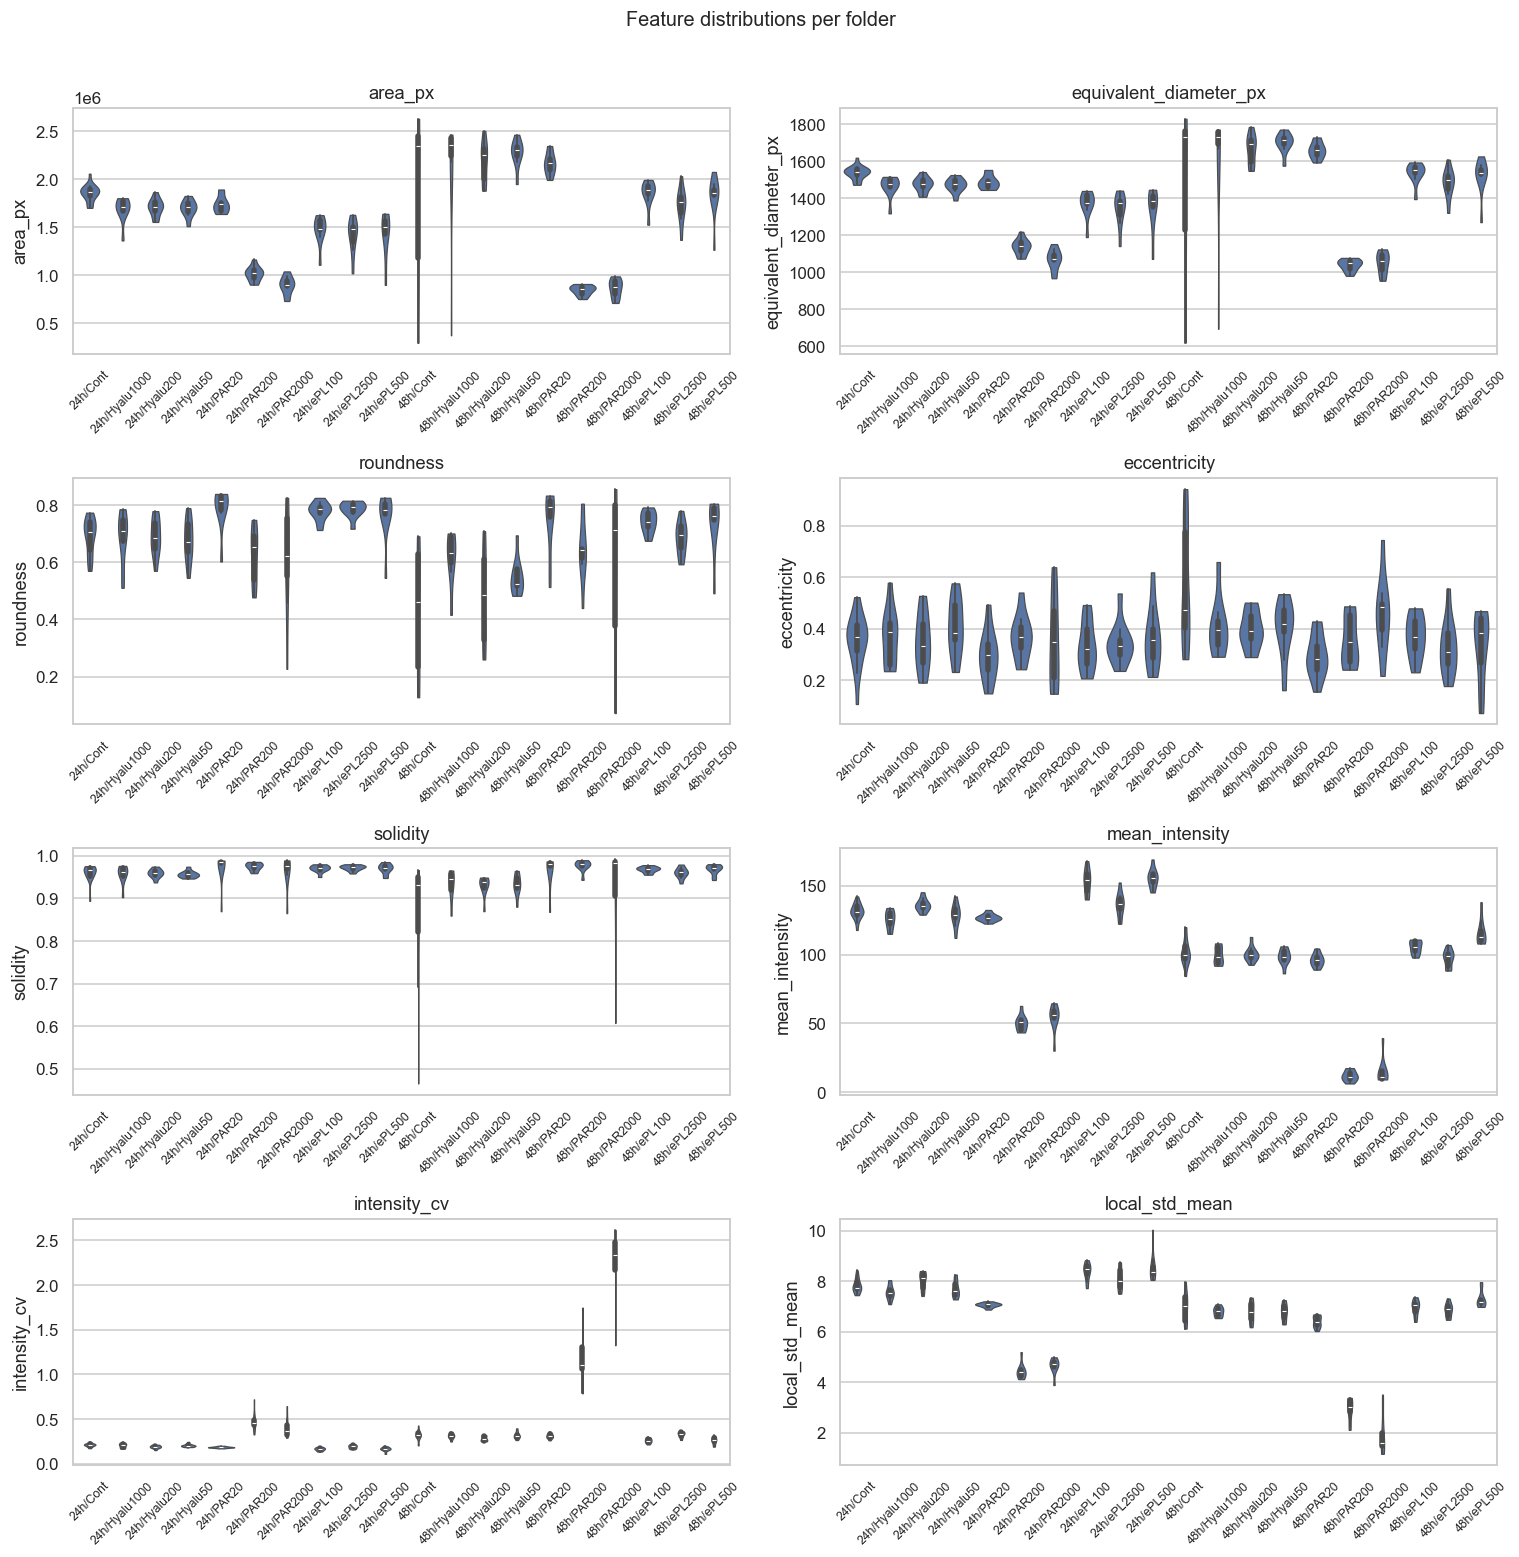

In [41]:
n_feat = len(PLOT_FEATURES)
n_cols = 2
n_rows = int(np.ceil(n_feat / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, feat in zip(axes, PLOT_FEATURES):
    sns.violinplot(
        data=plot_df, x="folder_norm", y=feat, order=folders_ordered,
        inner="box", cut=0, ax=ax, linewidth=0.8,
    )
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=8)

for ax in axes[len(PLOT_FEATURES):]:
    ax.set_visible(False)

fig.suptitle("Feature distributions per folder", y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_violin_per_folder.png", bbox_inches="tight")
plt.show()

### 2. Each folder vs Cont (24h and 48h separately)

One plot **per feature** and timepoint. X-axis lists every condition folder at that timepoint; **24h/Cont** or **48h/Cont** is highlighted in green, other folders in blue — so each condition is directly comparable to its control.

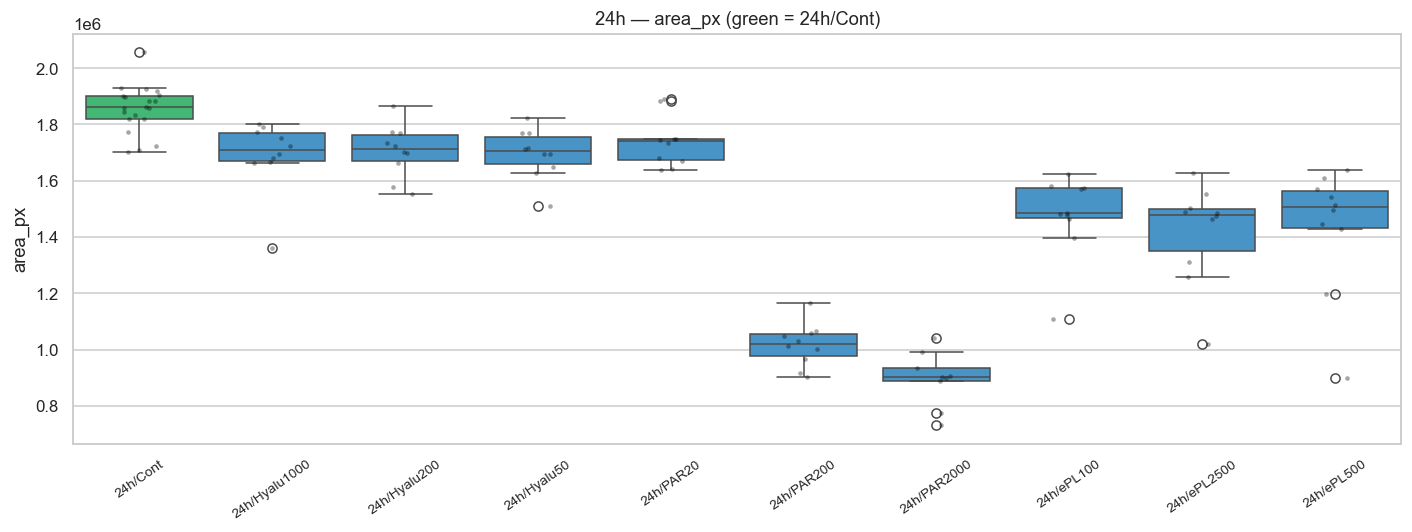

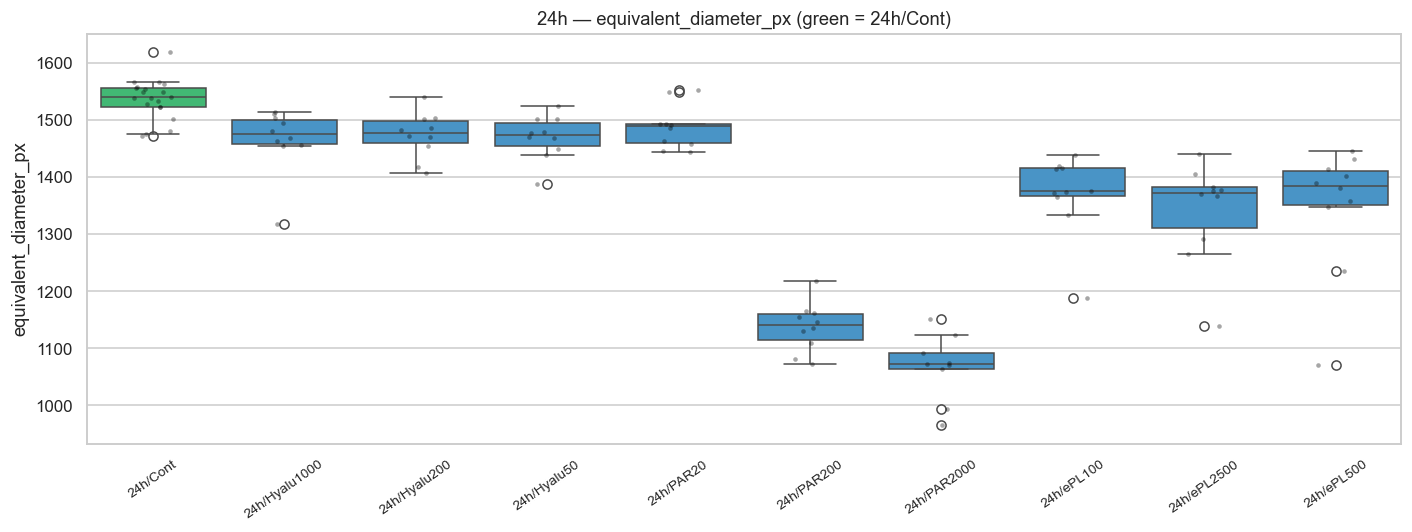

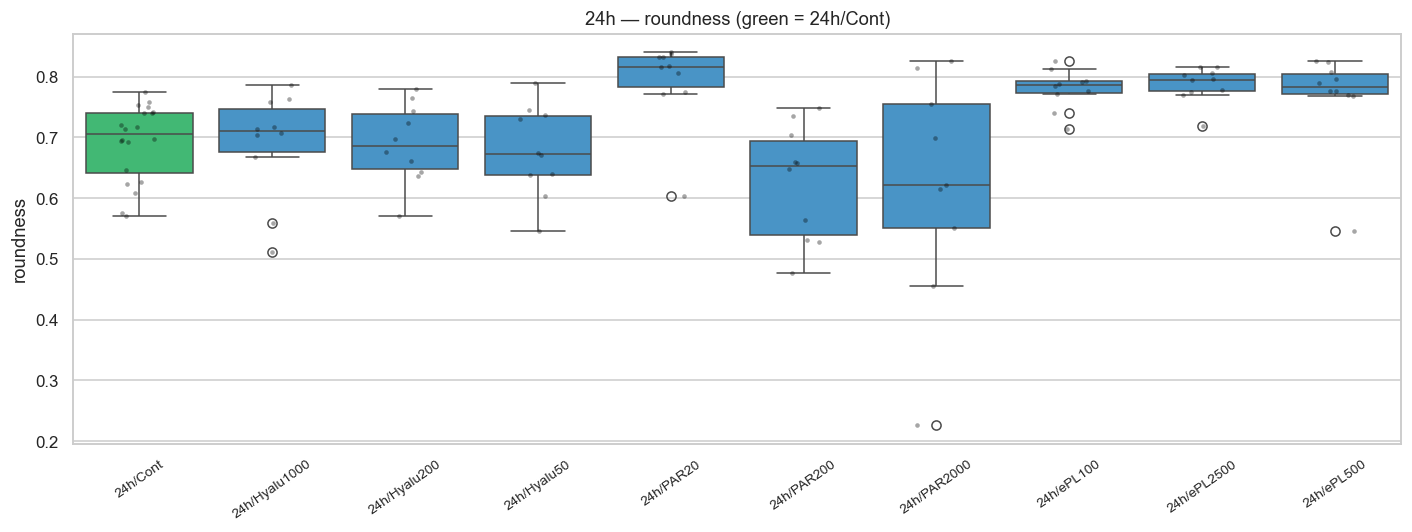

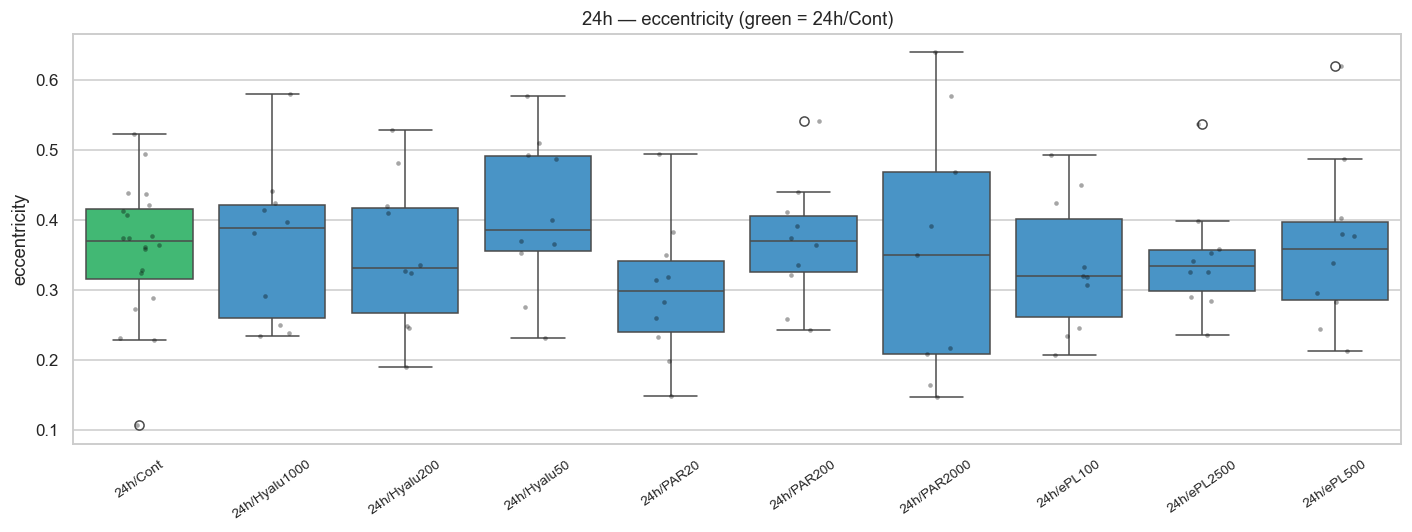

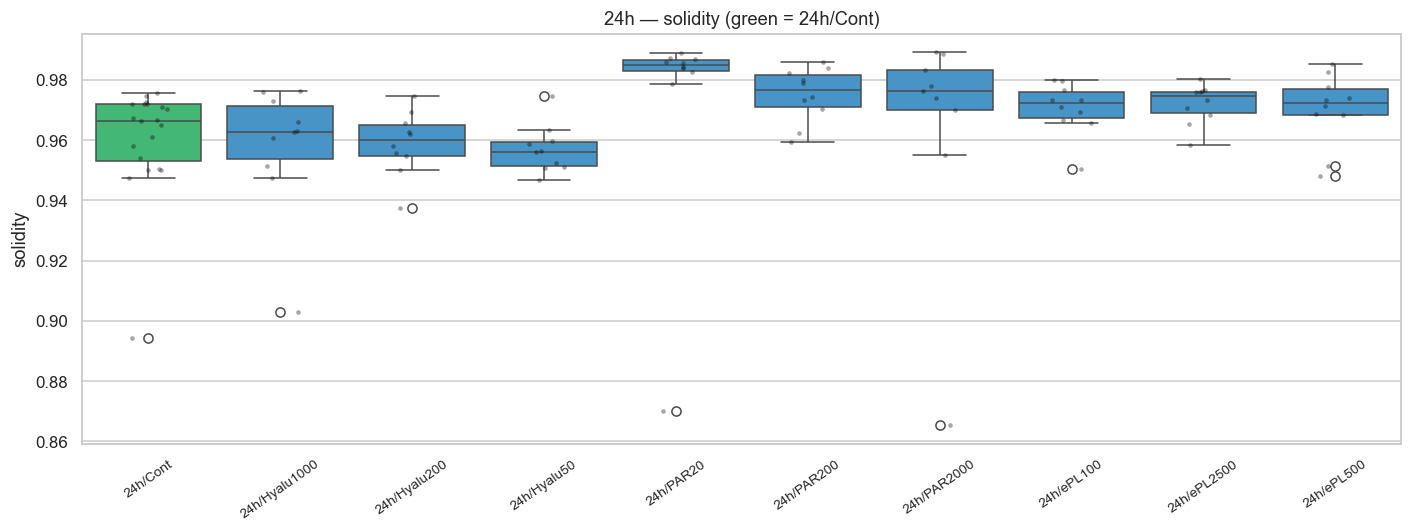

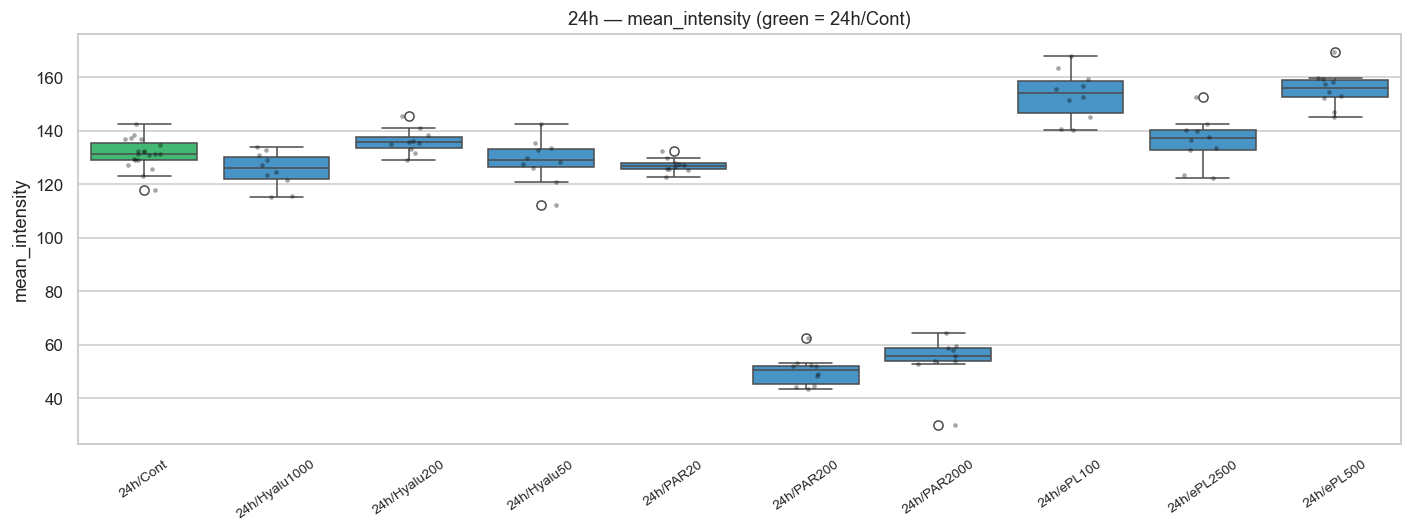

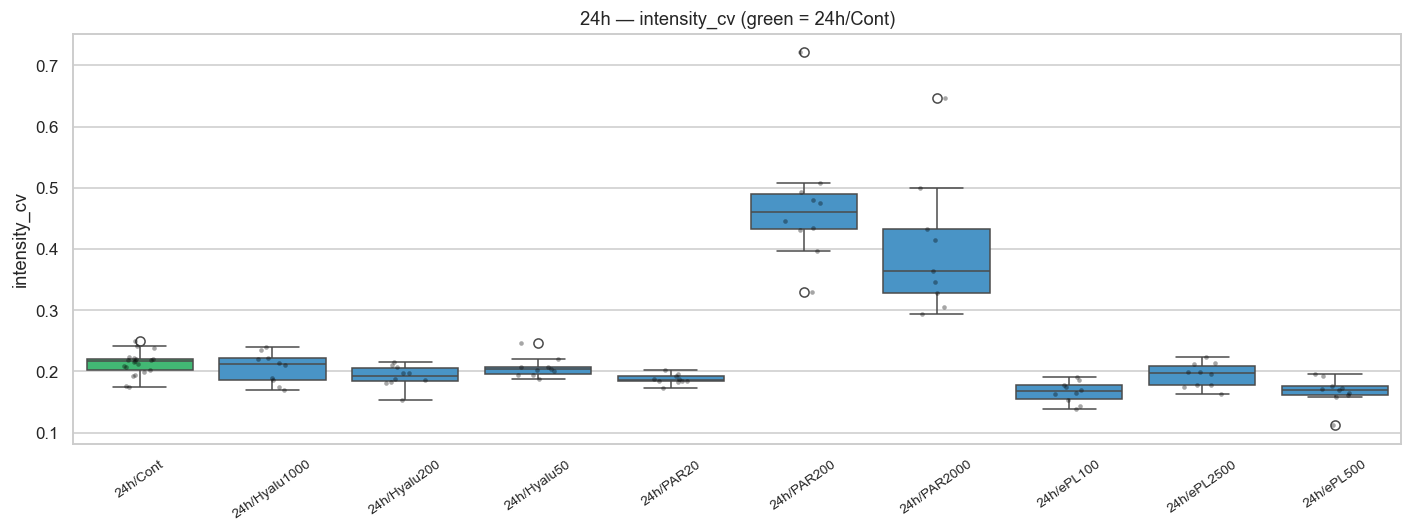

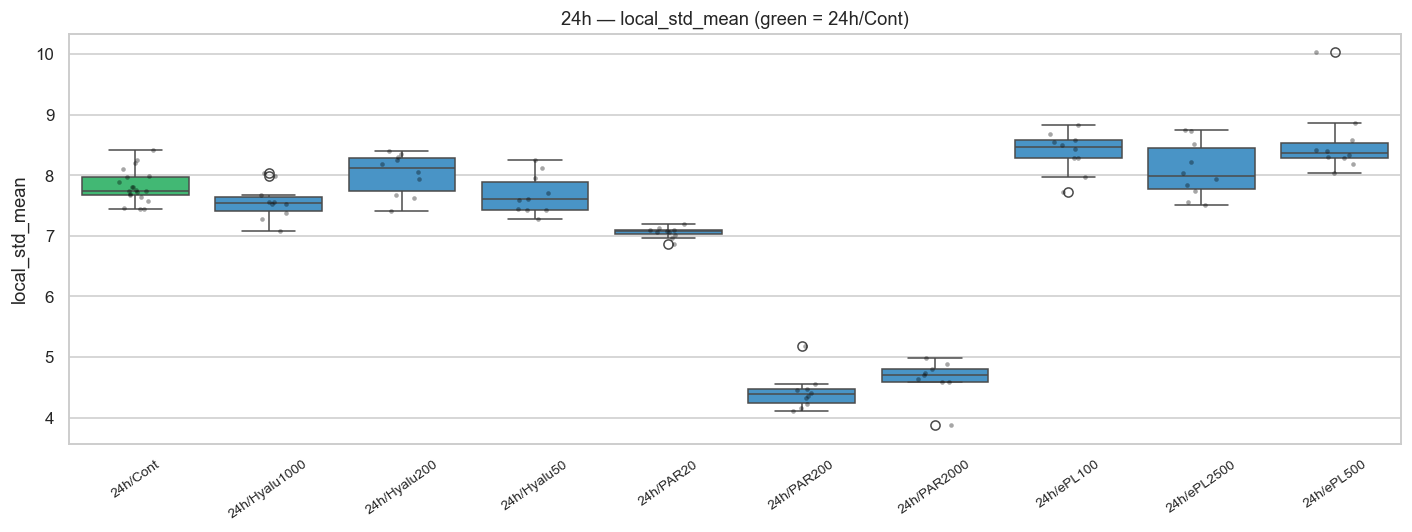

24h: saved 8 plots → D:\ToxBox\Preprocessing_KIT\spheroid_feature_figures\02_24h_vs_cont


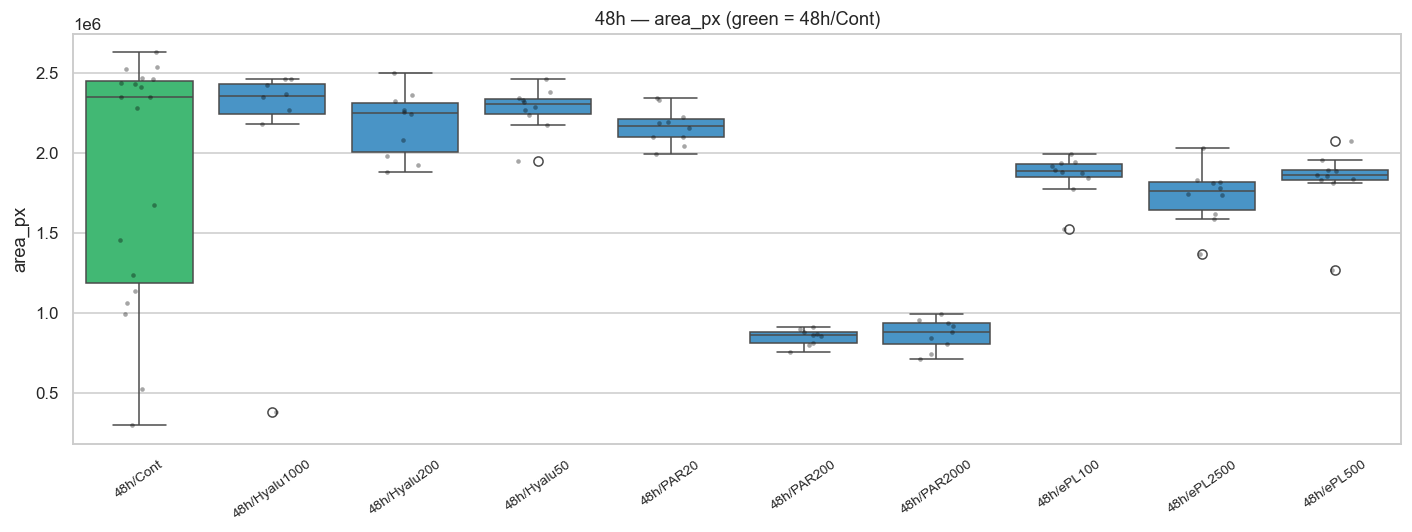

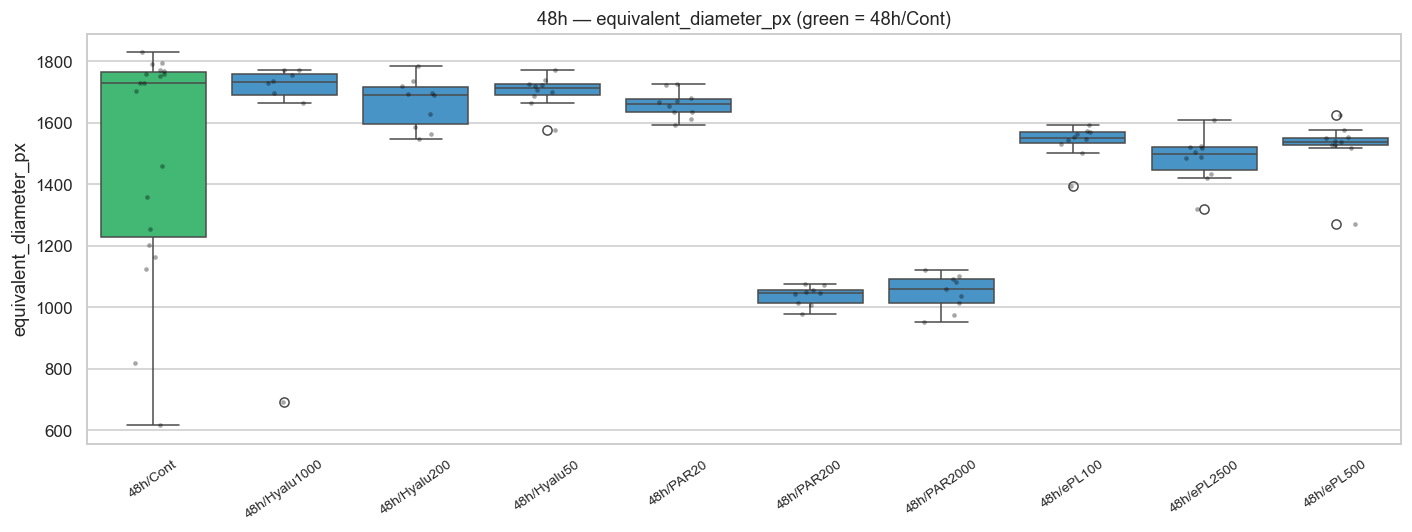

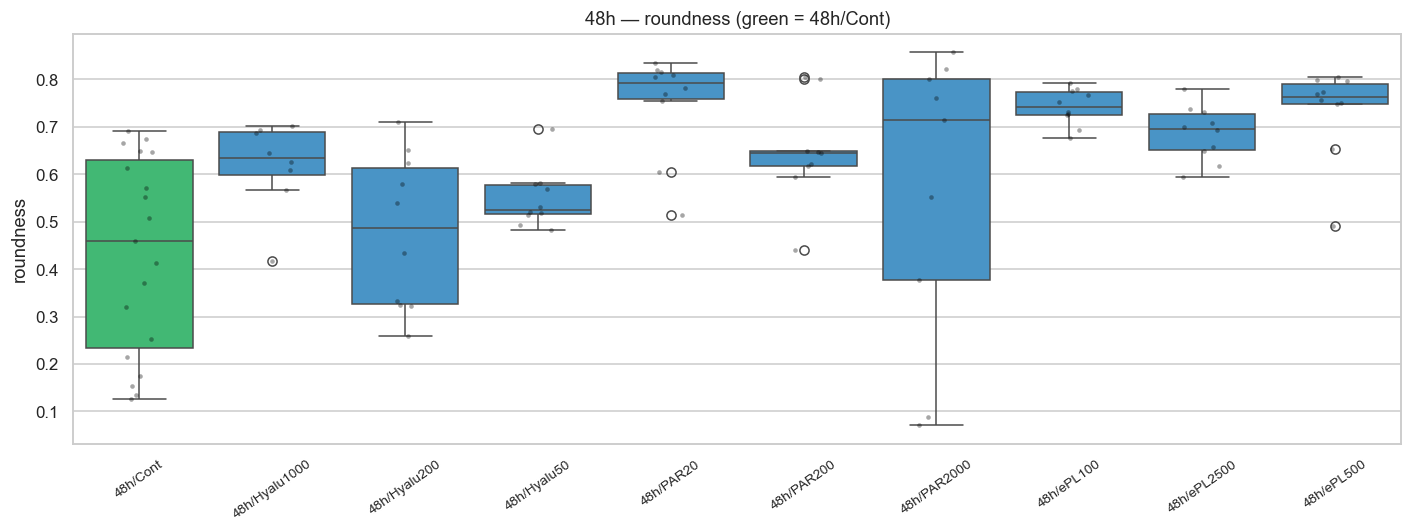

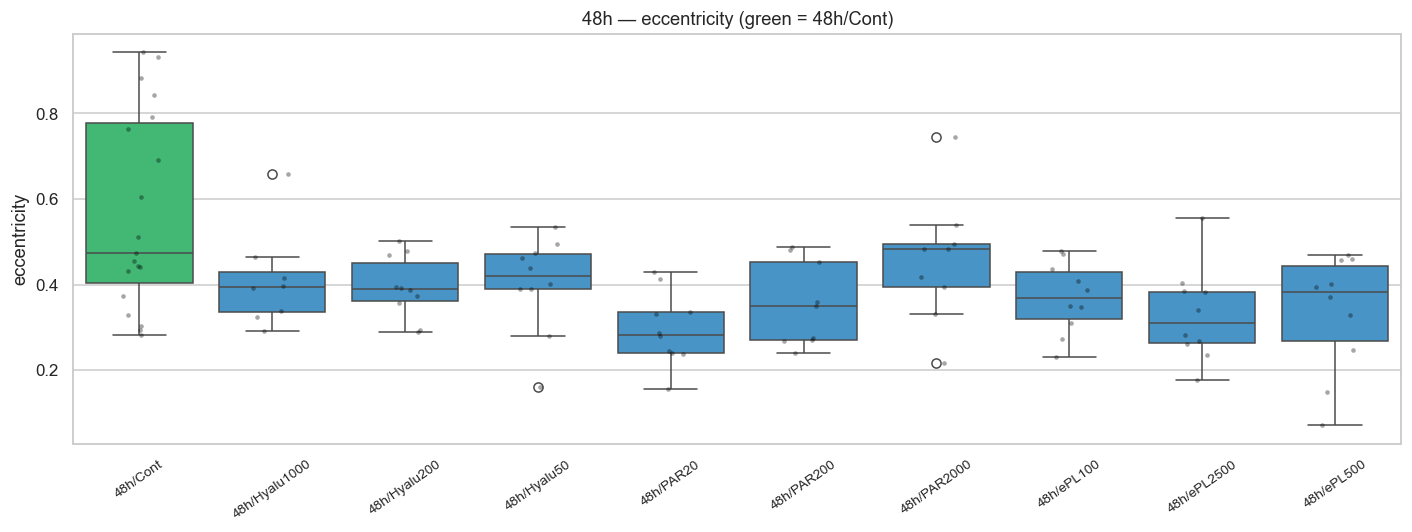

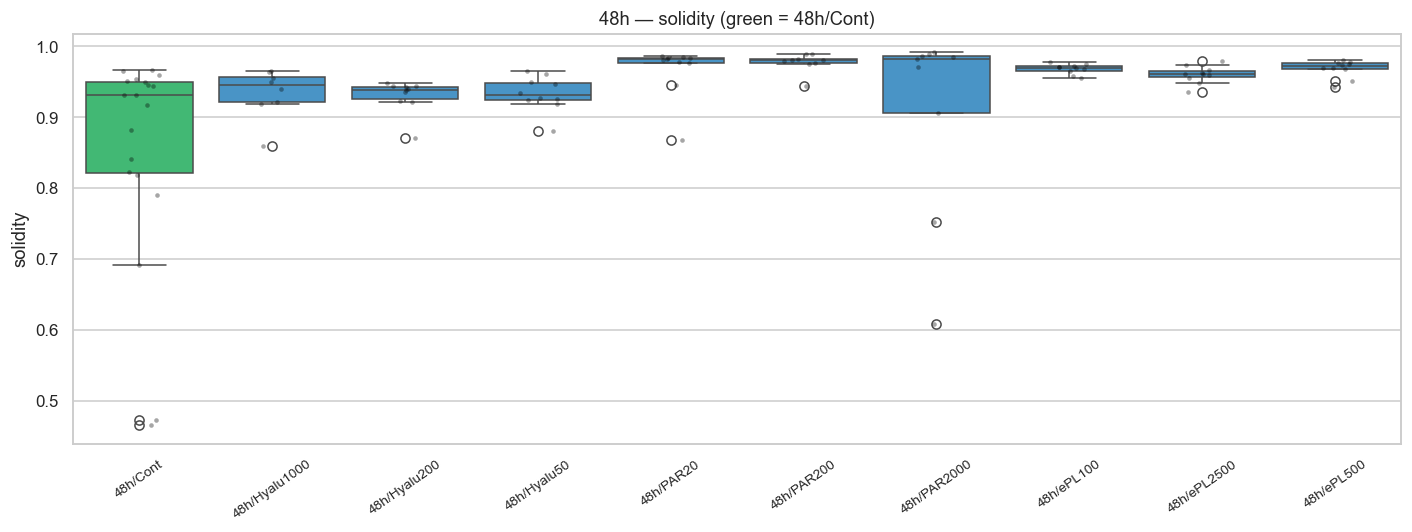

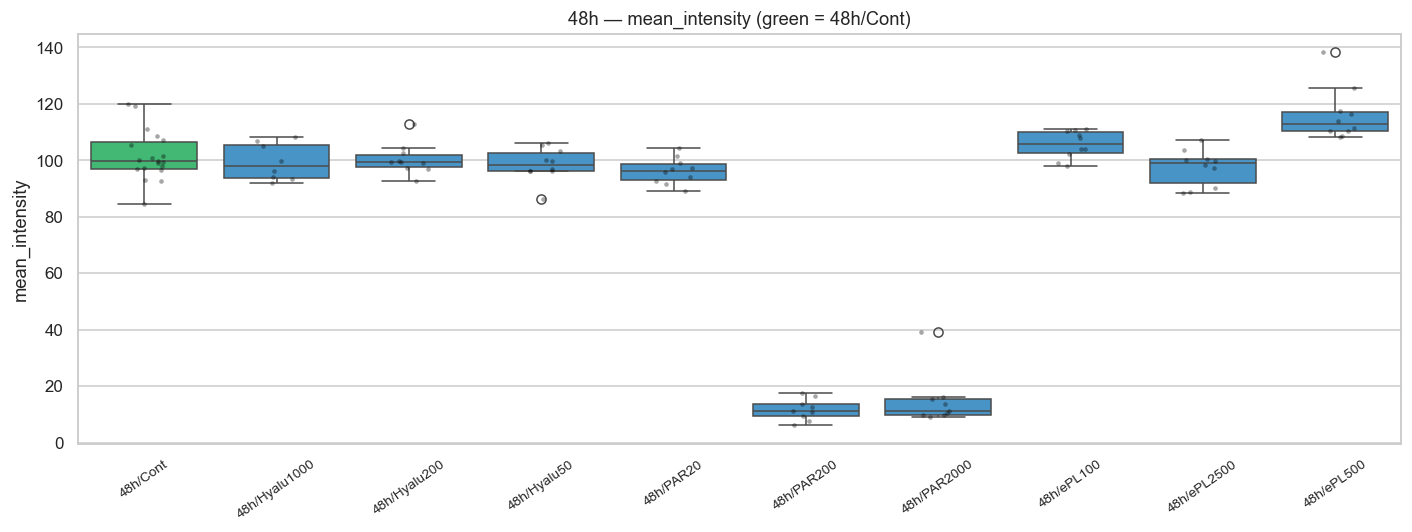

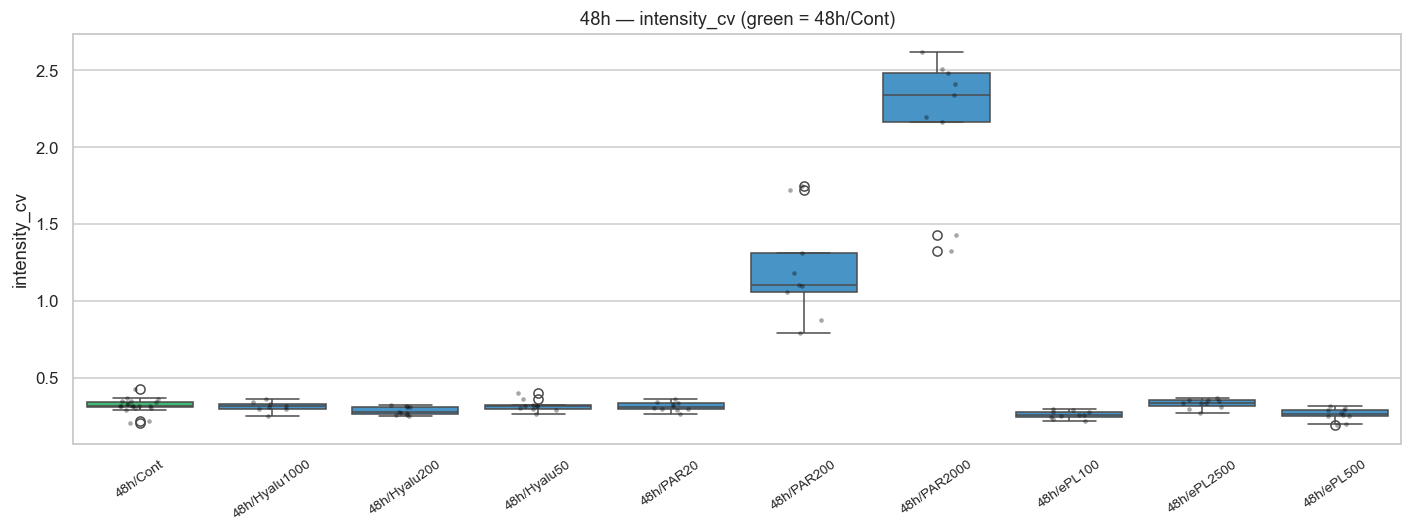

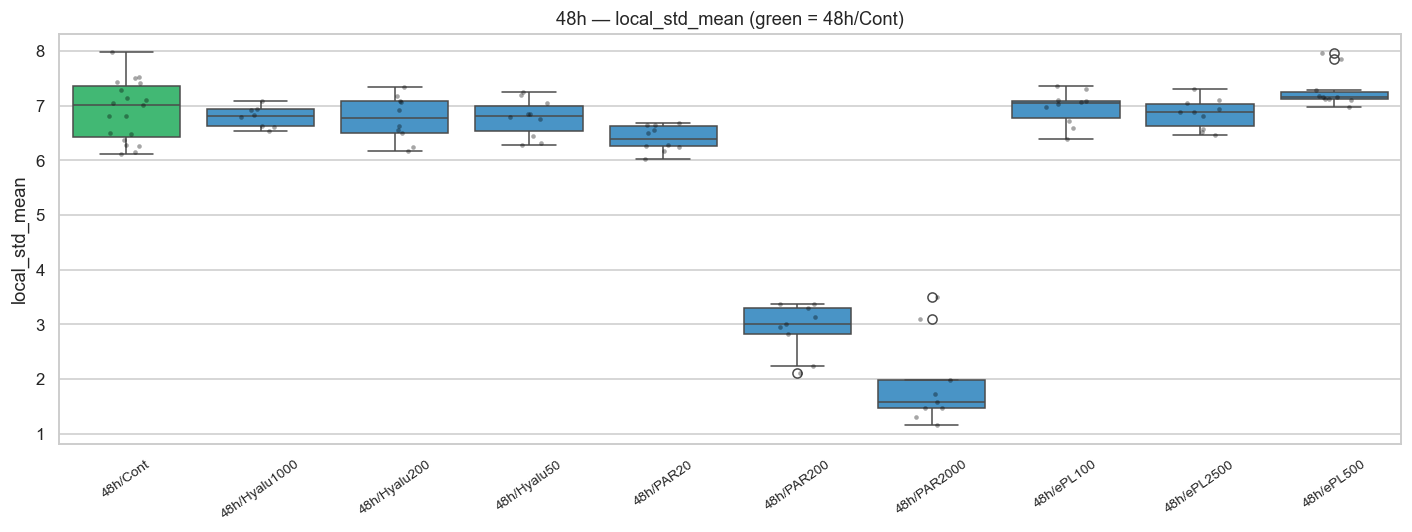

48h: saved 8 plots → D:\ToxBox\Preprocessing_KIT\spheroid_feature_figures\02_48h_vs_cont


In [42]:
CONT_COLOR = "#2ecc71"
OTHER_COLOR = "#3498db"


def folder_palette(folder_order, ref_folder):
    return {f: CONT_COLOR if f == ref_folder else OTHER_COLOR for f in folder_order}


for tp in ["24h", "48h"]:
    ref_folder = reference_folder_for_timepoint(tp)
    tp_df = plot_df[plot_df["timepoint"] == tp].copy()

    comparison_folders = sorted(
        f for f in tp_df["folder_norm"].unique()
        if f != ref_folder and not is_reference(f)
    )
    folder_order = [ref_folder] + comparison_folders

    if len(folder_order) < 2:
        print(f"{tp}: not enough folders to plot (need Cont + at least one condition)")
        continue

    out_dir = FIGURES_DIR / f"02_{tp}_vs_cont"
    out_dir.mkdir(parents=True, exist_ok=True)
    palette = folder_palette(folder_order, ref_folder)

    for feat in PLOT_FEATURES:
        plot_data = tp_df[tp_df["folder_norm"].isin(folder_order)]

        fig, ax = plt.subplots(figsize=(max(7, 1.3 * len(folder_order)), 5))
        sns.boxplot(
            data=plot_data,
            x="folder_norm",
            y=feat,
            hue="folder_norm",
            order=folder_order,
            hue_order=folder_order,
            palette=palette,
            dodge=False,
            legend=False,
            ax=ax,
        )
        sns.stripplot(
            data=plot_data,
            x="folder_norm",
            y=feat,
            order=folder_order,
            color="black",
            alpha=0.35,
            size=3,
            jitter=0.15,
            ax=ax,
        )
        ax.set_title(f"{tp} — {feat} (green = {ref_folder})")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=35, labelsize=9)
        fig.tight_layout()
        fig.savefig(out_dir / f"{feat}.png", bbox_inches="tight")
        plt.show()

    print(f"{tp}: saved {len(PLOT_FEATURES)} plots → {out_dir}")

### 3. Heatmap — mean feature profile per folder (z-scored)

Each row is a folder; each column is a feature. Colors show how far above/below the dataset mean that folder sits.

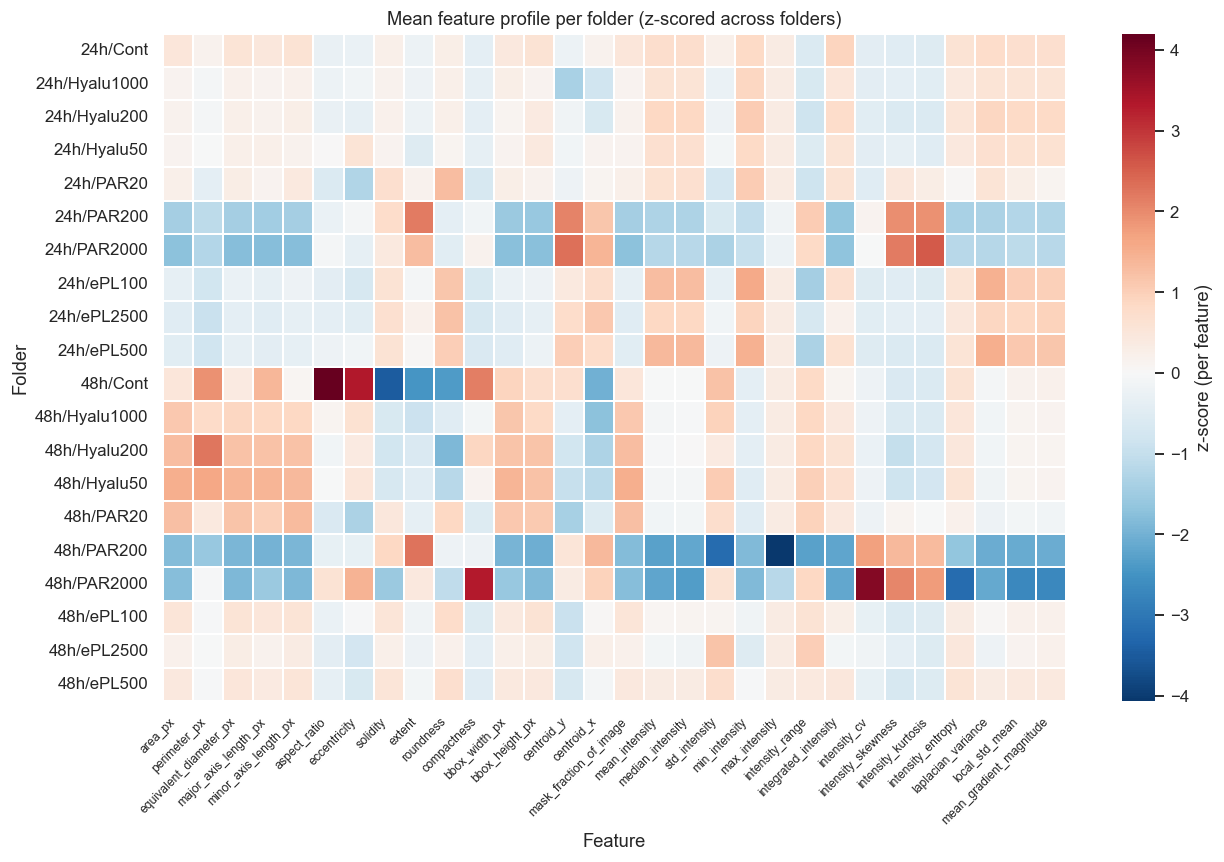

In [43]:
heatmap_features = [
    f for f in FEATURE_COLUMNS
    if f in plot_df.columns and plot_df[f].notna().any()
]

folder_means = plot_df.groupby("folder_norm")[heatmap_features].mean()
folder_z = (folder_means - folder_means.mean()) / folder_means.std(ddof=0)
folder_z = folder_z.fillna(0)

fig_h = max(4, 0.35 * len(folder_z) + 1)
fig, ax = plt.subplots(figsize=(12, fig_h))
sns.heatmap(
    folder_z, cmap="RdBu_r", center=0, annot=False,
    linewidths=0.3, ax=ax, cbar_kws={"label": "z-score (per feature)"},
)
ax.set_title("Mean feature profile per folder (z-scored across folders)")
ax.set_xlabel("Feature")
ax.set_ylabel("Folder")
plt.xticks(rotation=45, ha="right", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_heatmap_folder_profiles.png", bbox_inches="tight")
plt.show()

### 4. PCA — multivariate separation between folders

PCA using 30 features, 214 images


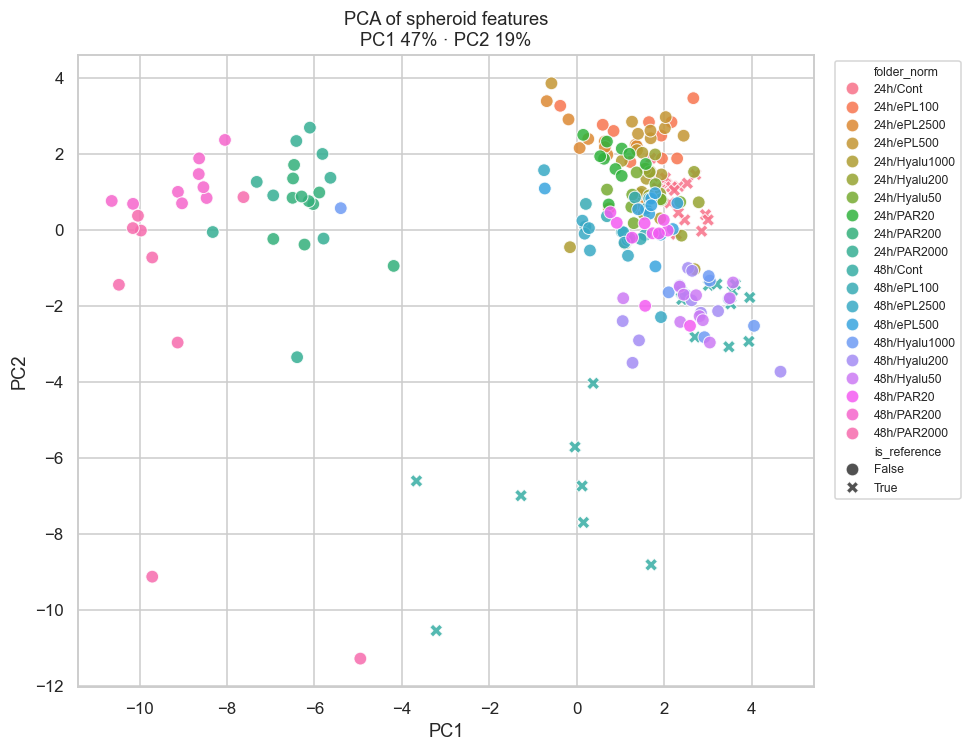

Top contributors to PC1:


,|loading|
integrated_intensity,0.257228
intensity_entropy,0.243432
bbox_height_px,0.235804
intensity_skewness,0.229807
local_std_mean,0.229771
mean_gradient_magnitude,0.226853
equivalent_diameter_px,0.226729
area_px,0.222707


In [44]:
pca_features = [f for f in FEATURE_COLUMNS if plot_df[f].notna().mean() > 0.95]
pca_df = plot_df.dropna(subset=pca_features).copy()
print(f"PCA using {len(pca_features)} features, {len(pca_df)} images")

X = StandardScaler().fit_transform(pca_df[pca_features])
pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X)
pca_df["PC1"] = coords[:, 0]
pca_df["PC2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2", hue="folder_norm",
    style="is_reference", s=70, alpha=0.85, ax=ax,
)
ax.set_title(
    f"PCA of spheroid features\n"
    f"PC1 {pca.explained_variance_ratio_[0]:.0%} · PC2 {pca.explained_variance_ratio_[1]:.0%}"
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_pca_by_folder.png", bbox_inches="tight")
plt.show()

loadings = pd.DataFrame(
    pca.components_.T, index=pca_features, columns=["PC1", "PC2"]
)
print("Top contributors to PC1:")
display(loadings["PC1"].abs().sort_values(ascending=False).head(8).to_frame("|loading|"))

### 5. Pairwise folder distance (Euclidean on z-scored means)

Shows which folders are most similar / different in average feature space.

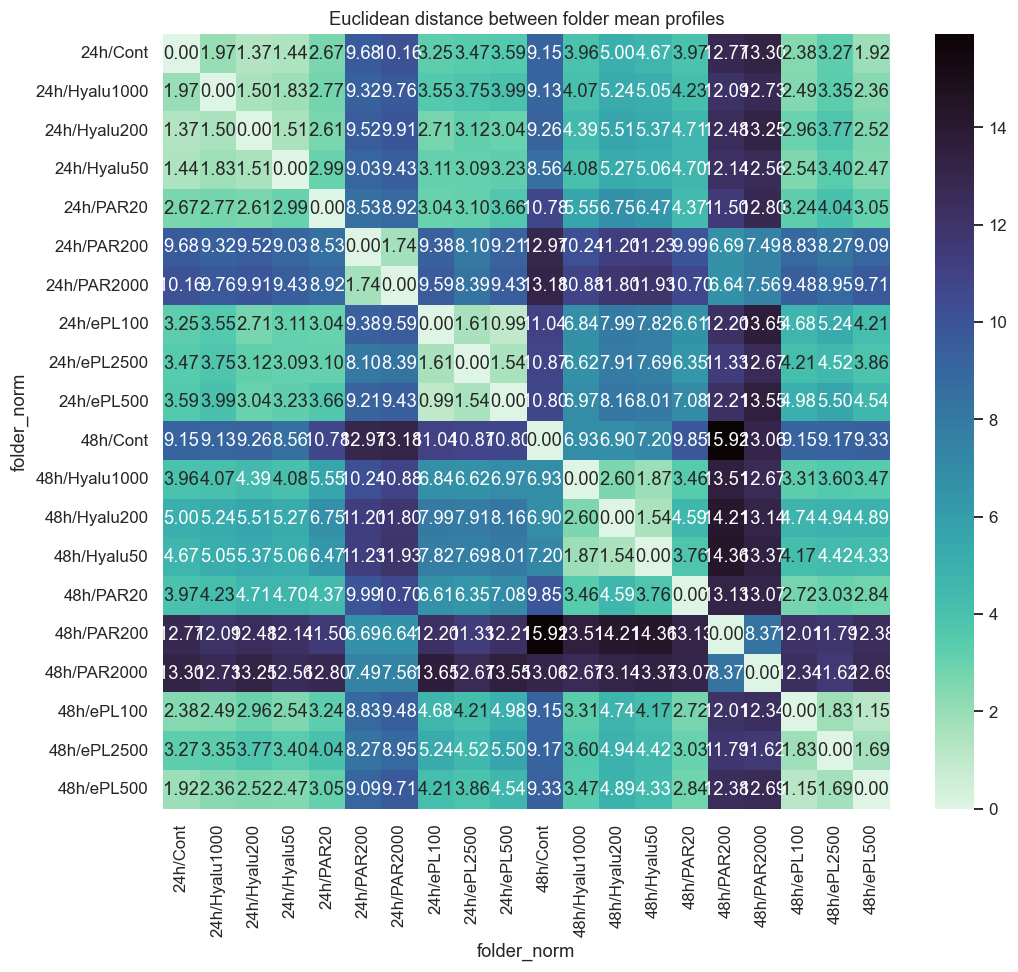

In [45]:
from scipy.spatial.distance import pdist, squareform

dist_vec = pdist(folder_z.values, metric="euclidean")
dist_mat = pd.DataFrame(
    squareform(dist_vec), index=folder_z.index, columns=folder_z.index,
)

fig, ax = plt.subplots(figsize=(max(6, 0.5 * len(dist_mat)), max(5, 0.45 * len(dist_mat))))
sns.heatmap(dist_mat, cmap="mako_r", annot=True, fmt=".2f", ax=ax)
ax.set_title("Euclidean distance between folder mean profiles")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_folder_distance_matrix.png", bbox_inches="tight")
plt.show()

### 6. Per-folder vs reference — effect size (Cohen's d)

For each folder and feature: how much that folder differs from the pooled reference group.

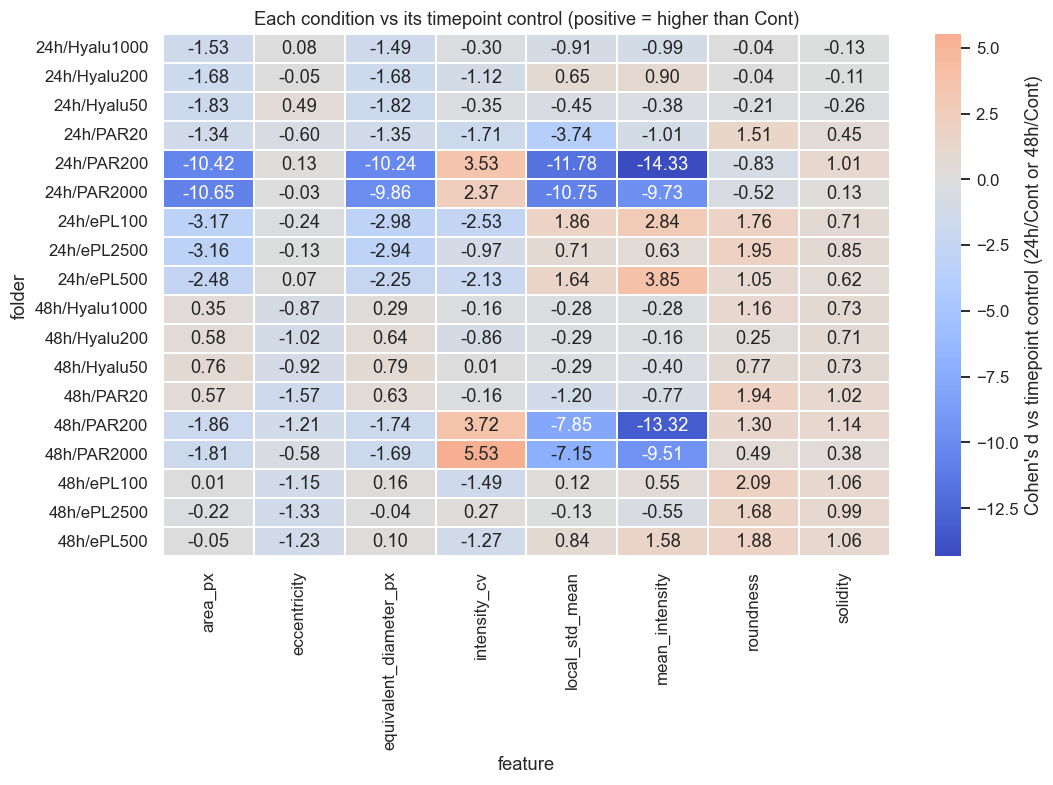

In [46]:
def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    if pooled < 1e-12:
        return np.nan
    return (a.mean() - b.mean()) / pooled


effect_rows = []
for folder in folders_ordered:
    if is_reference(folder):
        continue
    sub = plot_df.loc[plot_df["folder_norm"] == folder]
    tp = get_timepoint(folder)
    ref_path = reference_folder_for_timepoint(tp)
    if ref_path is None:
        continue
    ref_sub = plot_df.loc[plot_df["folder_norm"] == ref_path]
    if len(ref_sub) < 2 or len(sub) < 2:
        continue
    for feat in PLOT_FEATURES:
        effect_rows.append({
            "folder": folder,
            "timepoint": tp,
            "vs_control": ref_path,
            "feature": feat,
            "cohens_d_vs_cont": cohens_d(sub[feat], ref_sub[feat]),
        })

if not effect_rows:
    print("No comparison folders — check REFERENCE_FOLDERS paths match your data.")
else:
    effect_df = pd.DataFrame(effect_rows)
    effect_pivot = effect_df.pivot(index="folder", columns="feature", values="cohens_d_vs_cont")

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(effect_pivot) + 1)))
    sns.heatmap(
        effect_pivot, cmap="coolwarm", center=0, annot=True, fmt=".2f",
        linewidths=0.3, ax=ax,
        cbar_kws={"label": "Cohen's d vs timepoint control (24h/Cont or 48h/Cont)"},
    )
    ax.set_title("Each condition vs its timepoint control (positive = higher than Cont)")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "06_cohens_d_vs_cont.png", bbox_inches="tight")
    plt.show()

### 7. Summary table — median features per folder

In [47]:
summary = plot_df.groupby("folder_norm")[PLOT_FEATURES].agg(["median", "std", "count"])
summary.columns = ["_".join(c) for c in summary.columns]
display(summary.round(4))

summary_path = OUTPUT_CSV.with_name(OUTPUT_CSV.stem + "_summary_by_folder.csv")
summary.to_csv(summary_path)
print(f"Saved → {summary_path}")

,area_px_median,area_px_std,area_px_count,equivalent_diameter_px_median,equivalent_diameter_px_std,equivalent_diameter_px_count,roundness_median,roundness_std,roundness_count,eccentricity_median,...,solidity_count,mean_intensity_median,mean_intensity_std,mean_intensity_count,intensity_cv_median,intensity_cv_std,intensity_cv_count,local_std_mean_median,local_std_mean_std,local_std_mean_count
folder_norm,,,,,,,,,,,,,,,,,,,,,
24h/Cont,1861120.0,84398.8444,20,1539.3671,35.0098,20,0.7052,0.0623,20,0.3692,...,20,131.3512,5.5907,20,0.2167,0.0191,20,7.7431,0.2720,20
24h/Hyalu1000,1708317.5,126342.5408,10,1474.8080,56.8809,10,0.7107,0.0888,10,0.3889,...,10,125.9841,6.6005,10,0.2124,0.0249,10,7.5390,0.2903,10
24h/Hyalu200,1713815.0,92135.5917,10,1477.1844,39.9257,10,0.6865,0.0650,10,0.3313,...,10,135.6544,4.6678,10,0.1918,0.0179,10,8.1227,0.3441,10
24h/Hyalu50,1704760.0,87849.4825,10,1473.2805,38.4238,10,0.6729,0.0741,10,0.3853,...,10,128.9998,8.2737,10,0.2032,0.0166,10,7.6012,0.3273,10
24h/PAR20,1740087.5,89613.2123,10,1488.4700,38.0582,10,0.8167,0.0710,10,0.2984,...,10,126.7453,2.7297,10,0.1859,0.0082,10,7.0739,0.0916,10
24h/PAR200,1021083.0,76249.0732,10,1140.2005,42.5771,10,0.6532,0.0945,10,0.3693,...,10,50.6598,5.7460,10,0.4603,0.1020,10,4.3875,0.3028,10
24h/PAR2000,902201.0,95192.2506,9,1071.7826,57.4248,9,0.6224,0.1907,9,0.3497,...,9,55.8268,9.7288,9,0.3641,0.1125,9,4.7087,0.3160,9
24h/ePL100,1485133.5,146339.6796,10,1375.1109,71.0503,10,0.7866,0.0328,10,0.3193,...,10,154.0702,9.2764,10,0.1674,0.0175,10,8.4702,0.3339,10
24h/ePL2500,1478483.0,175988.5597,10,1372.0266,86.9562,10,0.7952,0.0291,10,0.3336,...,10,137.1146,8.8578,10,0.1974,0.0200,10,7.9903,0.4560,10


Saved → D:\ToxBox\Preprocessing_KIT\spheroid_features_summary_by_folder.csv
